# **Introdução** 

### Contexto

O serviço de telefonia virtual CallMeMaybe está desenvolvendo uma nova funcionalidade que permitirá aos supervisores **identificar operadores menos eficientes**.

Os clientes da empresa são **organizações que precisam gerenciar grandes volumes de chamadas** — tanto recebidas quanto realizadas por diversos operadores.

De acordo com as regras de negócio, um operador é considerado **ineficiente** se:

- Possui **muitas chamadas recebidas perdidas** (internas ou externas);
- Apresenta **tempo de espera prolongado** nas chamadas recebidas;
- E, no caso de operadores responsáveis por chamadas de saída, realiza **poucas chamadas ativas**.

### Dados

O dataset compactado **`telecom_dataset_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID da conta do cliente
- **`date`**: data em que as estatísticas foram coletadas
- **`direction`**: “direção” da chamada (`out` para chamadas **saídas**, `in` para chamadas **entrantes**)
- **`internal`**: indica se a chamada foi **interna** (entre operadores de um mesmo cliente)
- **`operator_id`**: identificador do operador
- **`is_missed_call`**: indica se foi uma **chamada perdida**
- **`calls_count`**: número de chamadas
- **`call_duration`**: duração da chamada (sem incluir o tempo de espera)
- **`total_call_duration`**: duração total da chamada (incluindo o tempo de espera)
O conjunto de dados **`telecom_clients_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID do cliente
- **`tariff_plan`**: plano tarifário atual do cliente
- **`date_start`**: data de registro do cliente

O conjunto de dados **`telecom_clients_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID do cliente
- **`tariff_plan`**: plano tarifário atual do cliente
- **`date_start`**: data de registro do cliente

### Objetivo 

O objetivo desta análise será identificar operadores com padrões abaixo do esperado com base em seu desempenho, sob a perspectiva de três métricas principais: chamadas perdidas, tempo de espera, e volume de chamadas outbound.  

# **Setup e Dados**

## Ambiente

### Importação bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st
from statsmodels.stats.proportion import proportions_ztest

### Configurações Globais

In [3]:
# reprodutibilidade — seed único
RANDOM_STATE = 42

# exibição de dados
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

### Carregamento de dados

In [4]:
# leitura arquivo CSV
telecom_raw = pd.read_csv('../data/raw/telecom_dataset_new.csv')

In [5]:
# leitura arquivo CSV
clients_raw = pd.read_csv('../data/raw/telecom_clients.csv')

## Pré Processamento 

### Primeiras impressões

#### *Telecom*

In [6]:
# primeira visualização
telecom_raw.head(10)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.00,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.00,True,3,0,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,False,2,3,29
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62


In [7]:
# descoberta informações sobre o dataframe
telecom_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB


Cada linha parece representar um agregado diário de chamadas.

O dataset *telecom* possui a nomenclatura de suas colunas dentro do padrão snake_case. 

Encontram-se valores ausentes nas colunas `internal` e `operator_id`. 

Seria mais adequado mudança no tipo de dado em colunas como `date` para `datetime` visando operações com datas, e `operator_id` e `user_id` para `str` por serem identificadores e não propriamente um valor numérico para cálculos.

#### *Clients*

In [8]:
# primeira visualização
clients_raw.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [9]:
# descoberta informações sobre o datafrane  
clients_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB


O dataset *clients* possui a nomenclatura de suas colunas dentro do padrão snake_case.

Não encontram-se valores ausentes.

Seria mais adequado mudança no tipo de dado na coluna `date_start` para `datetime`, visando operações com datas e `user_id` para `str` visando consitência.

### Tratamento de valores duplicados

In [10]:
# criação de cópias
telecom = telecom_raw.copy()
clients = clients_raw.copy()

In [11]:
# descoberta quantidade de valores duplicados
print(f'Número de registros duplicados no dataframe Telecom: {telecom.duplicated().sum()}')
print(f'Número de registros duplicados no dataframe Clients: {clients.duplicated().sum()}')

Número de registros duplicados no dataframe Telecom: 4900
Número de registros duplicados no dataframe Clients: 0


In [12]:
# visualização de registros duplicados
telecom[telecom.duplicated()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
44,166377,2019-08-14 00:00:00+03:00,out,False,880026.00,False,10,1567,1654
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
51,166377,2019-08-15 00:00:00+03:00,out,False,880026.00,False,11,1413,1473
...,...,...,...,...,...,...,...,...,...
53869,168601,2019-11-25 00:00:00+03:00,in,False,952914.00,False,7,1229,1282
53874,168601,2019-11-26 00:00:00+03:00,in,False,952914.00,False,4,539,562
53875,168601,2019-11-26 00:00:00+03:00,in,False,NaN,True,3,0,35
53885,168603,2019-11-20 00:00:00+03:00,out,False,959118.00,True,3,0,89


In [13]:
# visualização amostra registros de um operador aleatório
telecom_raw[telecom_raw['operator_id'] == 880020.00]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,False,1,10,18
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,False,2,3,29
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
11,166377,2019-08-06 00:00:00+03:00,out,False,880020.00,True,5,0,70
13,166377,2019-08-06 00:00:00+03:00,out,False,880020.00,False,5,800,819
16,166377,2019-08-07 00:00:00+03:00,out,False,880020.00,False,2,232,240
76,166377,2019-08-22 00:00:00+03:00,in,False,880020.00,False,1,33,49
124,166377,2019-09-02 00:00:00+03:00,out,True,880020.00,True,2,0,0


In [14]:
# remoção dados duplicados
telecom = telecom.drop_duplicates().reset_index(drop=True)

**Decisão Metodológica**: remoção de duplicatas.

4.900 linhas duplicadas identificadas (~9% do dataset original de 53.902 linhas). 

Critério: linha completamente idêntica em todas as 9 colunas. 

Dataset após limpeza: 49.002 linhas.

Cada linha representa um agregado por combinação única de (`user_id`, `date`, `direction`, `internal`, `operator_id`, `is_missed_call`). 

Dentro desta estrutura, dois registos com valores idênticos em todas as colunas são impossíveis como dado legítimo — confirmado na inspeção do operador 880020 (índices 6 e 8: linha idêntica em todas as 9 colunas).

### Tratamento de valores nulos

In [15]:
# descoberta quantidade registros ausentes dataset telecom
telecom.isnull().sum()

user_id                   0
date                      0
direction                 0
internal                110
operator_id            7456
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

Valores nulos em duas colunas: `internal` e `operator_id`.

In [16]:
# descoberta quantidade registros ausentes dataset clients
clients.isnull().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [17]:
# visualização de registros ausentes na coluna internal
telecom[telecom['internal'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
917,166405,2019-09-18 00:00:00+03:00,in,NaN,NaN,True,1,0,59
996,166405,2019-10-01 00:00:00+03:00,in,NaN,NaN,True,1,0,1
1705,166406,2019-08-20 00:00:00+03:00,in,NaN,NaN,True,1,0,36
1761,166406,2019-09-02 00:00:00+03:00,in,NaN,879898.00,False,1,2,9
5645,166541,2019-09-26 00:00:00+03:00,in,NaN,908960.00,False,1,393,423
...,...,...,...,...,...,...,...,...,...
47702,168361,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,6,0,14
47819,168361,2019-11-13 00:00:00+03:00,in,NaN,NaN,True,2,0,6
47844,168361,2019-11-14 00:00:00+03:00,in,NaN,NaN,True,1,0,2
48837,168579,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,1,0,18


In [18]:
# visualização de registros ausentes na coluna operator_id
telecom[telecom['operator_id'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62
16,166377,2019-08-07 00:00:00+03:00,in,False,NaN,True,2,0,24
26,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
...,...,...,...,...,...,...,...,...,...
48978,168601,2019-11-27 00:00:00+03:00,in,False,NaN,True,2,0,39
48982,168601,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,19
48990,168603,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,30
48994,168606,2019-11-08 00:00:00+03:00,in,False,NaN,True,6,0,121


In [19]:
# contagem de chamadas perdidas dentre os operadores não identificados
telecom[telecom['operator_id'].isnull()]['is_missed_call'].value_counts()

is_missed_call
True     7343
False     113
Name: count, dtype: int64

A maioria esmagadora (~98,5%) de valores nulos na coluna `operator_id` são referentes a chamadas perdidas. 

In [20]:
# contagem de chamadas inbound dentre os operadores não identificados
telecom[telecom['operator_id'].isnull()]['direction'].value_counts()

direction
in     7270
out     186
Name: count, dtype: int64

A maioria esmagadora (~97,5%) de valores nulos na coluna `operator_id` são referentes a chamadas inbound.

In [21]:
telecom[telecom['is_missed_call'] == True].shape[0]

21453

Um volume infímo de 110 chamadas (~0,22%) não possuem identificação se foram entre operadores de um mesmo cliente.

Cerca de 34,2% do total de chamadas perdidas do dataset não possuem operador identificado.

Padrão consistente com chamadas que chegaram ao sistema mas nunca foram atribuídas a um operador.

**DECISÃO METODOLÓGICA**:
manutenção de registros de chamada sem operador atrelado e identificação se foram entre operadores de um mesmo cliente.

Das 7.456 linhas com `operator_id` nulo:
- 7.270 (~97.5%) são chamadas inbound
- 7.343 (~98.5%) têm `is_missed_call = True`
- Representam 34.2% do total de chamadas perdidas do dataset (7.343 / 21.453)

Interpretação: chamadas que chegaram ao sistema mas nunca foram atribuídas a um operador — não existe operador a avaliar individualmente. Estas linhas são mantidas no dataset completo para preservar a taxa real de chamadas perdidas ao nível da empresa, mas são excluídas automaticamente nas análises por operador por ausência de `operator_id`.

### Alterações de tipos de dados

In [22]:
# conversões de indicadores para str
telecom['user_id']= telecom['user_id'].astype('str')
telecom['operator_id'] = telecom['operator_id'].astype(str).replace('nan', pd.NA)
clients['user_id'] = clients['user_id'].astype('str')

In [23]:
# conversões para datetime
telecom['date'] = pd.to_datetime(telecom['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])

### Engenharia de features

In [84]:
# criação coluna tempo de espera
telecom['waiting_time'] = telecom['total_call_duration'] - telecom['call_duration']
telecom['waiting_time_per_call'] = telecom['waiting_time'] / telecom['calls_count']
print(f"Registros com tempo de espera negativo: {(telecom['waiting_time'] < 0).sum()}")

Registros com tempo de espera negativo: 0


In [25]:
# criação coluna mês
telecom['month'] = telecom['date'].dt.month 

In [26]:
# criação coluna semana
telecom['week'] = telecom['date'].dt.isocalendar().week 

In [27]:
# criação dataframe agregado entre duas tablas base
telecom_merged = telecom.merge(
    clients, 
    on='user_id',
    how='left'
)

In [28]:
# filtro para análise sem dados nulos
telecom_ops = telecom_merged[telecom_merged['operator_id'].notna()].copy()
telecom_ops = telecom_ops[telecom_ops['internal'].notna()].copy()

# **EDA**

### Investigação variáveis chave

#### Tempo de espera

In [85]:
# descoberta características variável chave tempo de espera
telecom_ops['waiting_time_per_call'].describe()

count   41491.00
mean       16.54
std        11.95
min         0.00
25%         8.50
50%        14.67
75%        21.72
max       451.20
Name: waiting_time_per_call, dtype: float64

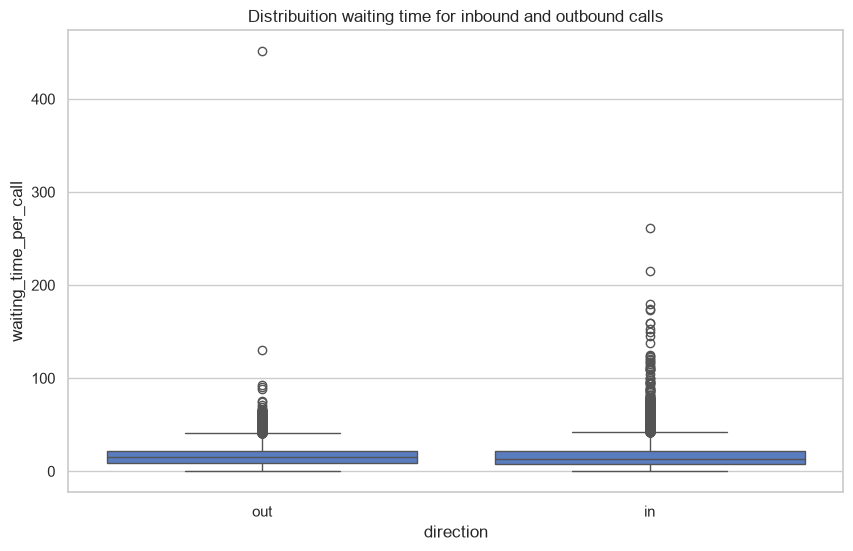

In [86]:
# criação boxplot para visualização variável contínua
sns.boxplot(
    data=telecom_ops, 
    x='direction', 
    y='waiting_time_per_call'
)
plt.title('Distribuition waiting time for inbound and outbound calls')
plt.show()

In [91]:
# descoberta características tempo de espera para chamadas inbound
telecom_ops[telecom_ops['direction'] == 'in']['waiting_time_per_call'].describe(percentiles=[.25, .50, .66, .75, .85, .90, .95])

count   12678.00
mean       16.48
std        13.56
min         0.00
25%         7.67
50%        13.00
66%        17.75
75%        21.33
85%        27.50
90%        32.00
95%        40.50
max       261.00
Name: waiting_time_per_call, dtype: float64

A distribuição é fortemente assimétrica à direita na distriuição da variável alvo `waiting_time`, tanto em chamadas inbound e outbound. 

A maioria dos registros tem tempos de espera relativamente curtos, enquanto uma minoria de registros apresenta tempos de espera extremamente longos, gerando valores atípicos na cauda superior da distribuição.

Os outliers inbound atingem valores ~20x superiores à mediana (mediana inbound ~13s, máximo inbound ~261s).

#### Contagem de chamadas

In [32]:
# descoberta características variável chave contagem de chamadas
telecom_ops['calls_count'].describe()

count   41491.00
mean       16.92
std        59.79
min         1.00
25%         1.00
50%         4.00
75%        14.00
max      4817.00
Name: calls_count, dtype: float64

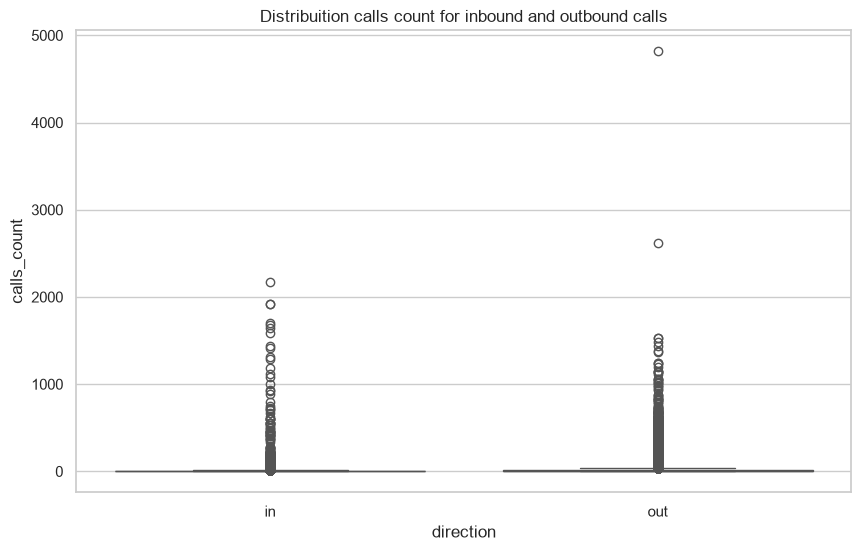

In [33]:
# criação boxplot para variável contínua
sns.boxplot(
    data=telecom, 
    x='direction', 
    y='calls_count'
)
plt.title('Distribuition calls count for inbound and outbound calls')
plt.show()

In [34]:
# descoberta características contagem de chamadas para outbound
telecom_ops[telecom_ops['direction'] == 'out']['calls_count'].describe()

count   28813.00
mean       21.11
std        70.64
min         1.00
25%         2.00
50%         5.00
75%        18.00
max      4817.00
Name: calls_count, dtype: float64

A distribuição é fortemente assimétrica à direita na distriuição da variável alvo `calls_count`, tanto em chamadas inbound e outbound. 

A maioria das observações envolve apenas algumas chamadas, enquanto um número pequeno de registos apresenta volumes de chamadas excepcionalmente elevados, gerando numerosos valores atípicos na cauda superior da distribuição.

Dentro das chamada outbound valor máximo atinge 4817 chamadas, apesar de a mediana ser de apenas 5.

#### Chamadas perdidas

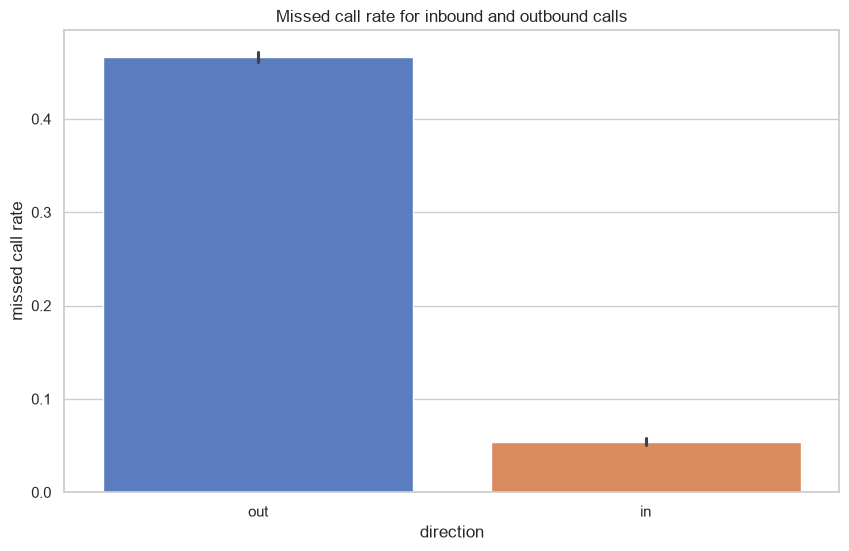

In [35]:
# criação gráfico de barras para variável categórica
sns.barplot(
    data=telecom_ops,
    x='direction',
    y='is_missed_call',
    hue='direction'
)
plt.title('Missed call rate for inbound and outbound calls')
plt.ylabel('missed call rate')
plt.show()

As chamadas inbound apresentam um desequilíbrio acentuado no que diz respeito à variável-alvo `is_missed_call`. 

A maioria das chamadas inbound foi atendida, enquanto as chamadas perdidas representam apenas uma pequena fração das observações (~5%). 

Em contrapartida, as chamadas outbound apresentam uma distribuição muito mais equilibrada entre chamadas atendidas e chamadas perdidas (~45%).

A taxa outbound elevada pode reflectir comportamento normal de contacto (destinatário não atende). Por esta razão, a avaliação de operadores é calculado exclusivamente sobre chamadas inbound.

### Volumes temporais

In [36]:
telecom_ops['month'].unique()

array([ 8,  9, 10, 11], dtype=int32)

O período de registros do dataset cobre os meses de Agosto, Setembro, Outubro e Novembro.

#### Volume semanal de chamadas

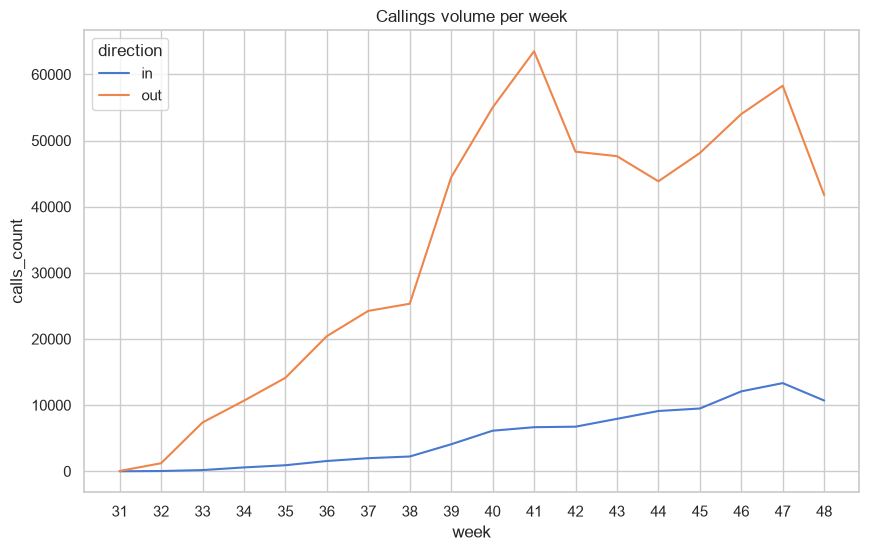

In [37]:
# criação gráfico de linhas para visualização temporal
sns.lineplot(data=telecom_ops.groupby(['week', 'direction'])['calls_count'].sum().reset_index(), x='week', y='calls_count', hue='direction')
plt.title('Callings volume per week')
plt.xticks(telecom['week'].unique())
plt.show()

É notável o crescimento do volume de chamadas registrados durante o período de observação.  

Enquanto as chamadas outbound tem crescimento acelerado, as chamadas inbound seguiu ritmo mais lento (outbound ~40.000 x ~10.000 inbound ao fim do período de observação).

#### Volume semanal de operadores

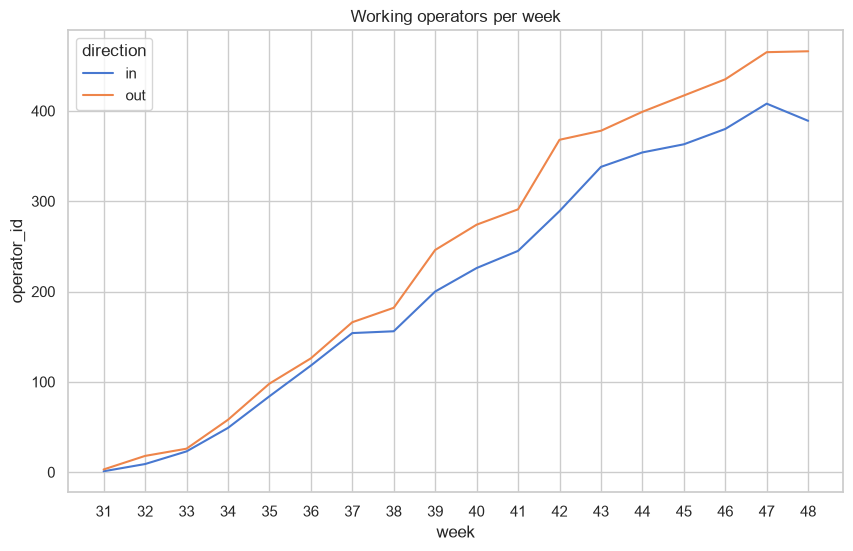

In [38]:
# criação gráfico de linhas para visualização temporal
sns.lineplot(data=telecom_ops.groupby(['week', 'direction'])['operator_id'].nunique().reset_index(), x='week', y='operator_id', hue='direction')
plt.title('Working operators per week')
plt.xticks(telecom_ops['week'].unique())
plt.show()

É notável o crescimento do volume de operadores registrados durante o período de observação.  

Contudo, diferente do que foi observado no volume de chamadas, o número de operadores de outbound e inbound cresceram numa proporção similar.

#### Volume semanal de chamadas inbound perdidas

In [39]:
# criação agregado semanal chamadas inbound
weekly_inbound_ratio = (
    telecom_ops[
        telecom_ops['direction'] == 'in'
    ]
    .groupby('week')['calls_count']
    .sum()
    .reset_index()
)

In [40]:
# contagem de chamadas inbound perdidas
missed_inbound_calls = (
    telecom_ops[
        (telecom_ops['direction'] == 'in') &
        (telecom_ops['is_missed_call'] == True)
    ]
    .groupby('week', as_index=False)['calls_count']
    .sum()
    .rename(columns={'calls_count': 'missed_calls'})
)

In [41]:
# união resultado ao agregado
weekly_inbound_ratio = weekly_inbound_ratio.merge(
    missed_inbound_calls,
    on='week',
    how='left'
)

In [42]:
# criação coluna ratio 
weekly_inbound_ratio['missed_rate'] = weekly_inbound_ratio['missed_calls'] / weekly_inbound_ratio['calls_count'] 

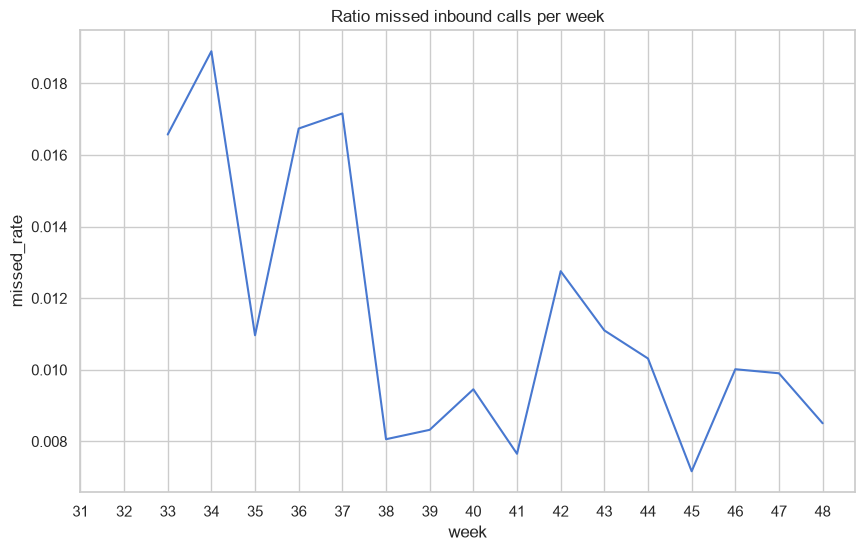

In [43]:
# criação gráfico de linhas para visualização temporal
sns.lineplot(data=weekly_inbound_ratio, x='week', y='missed_rate')
plt.title('Ratio missed inbound calls per week')
plt.xticks(weekly_inbound_ratio['week'].unique())
plt.show()

A taxa de chamadas perdidas apresenta comportamento com tendência de queda com o avançar das semanas (de ~0.02% para ~0.01%) apesar do aumento no volume de chamadas.

### Investigação operadores

#### Distribuições volume de chamadas por operador 

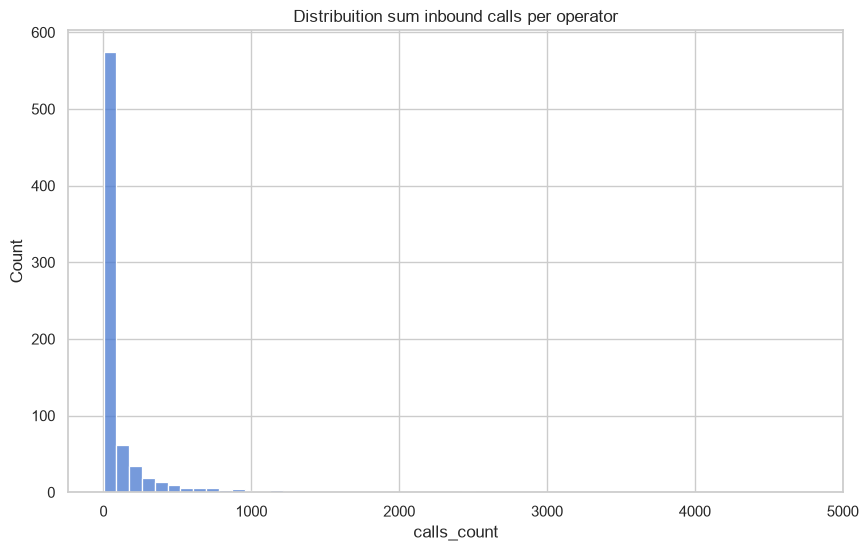

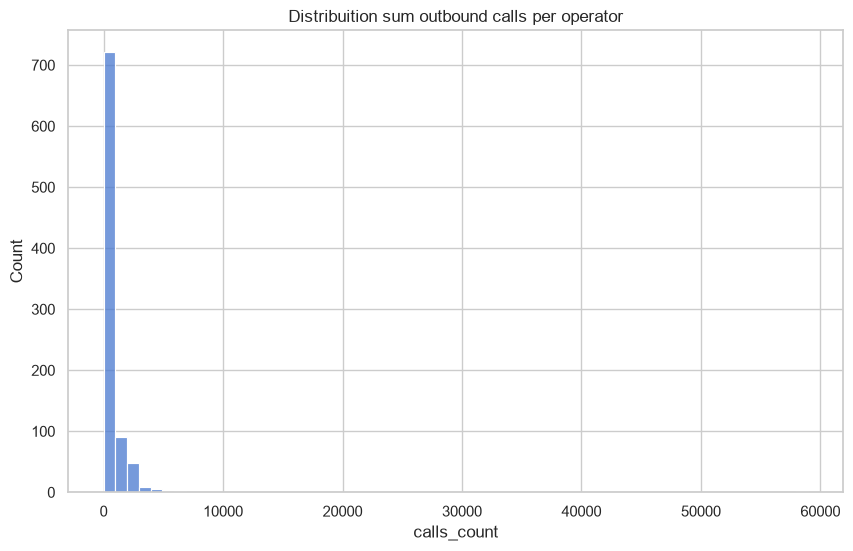

In [44]:
# visualização distribuição do número de chamadas por operador inbound
sns.histplot(telecom_ops[telecom_ops['direction'] == 'in'].groupby('operator_id')['calls_count'].sum())
plt.title('Distribuition sum inbound calls per operator')
plt.show()

# visualização distribuição do número de chamadas por operador outboubd
sns.histplot(telecom_ops[telecom_ops['direction'] == 'out'].groupby('operator_id')['calls_count'].sum())
plt.title('Distribuition sum outbound calls per operator')
plt.show()

In [45]:
# visualização características soma de chamadas inbound por operador
telecom_ops[telecom_ops['direction'] == 'in'].groupby('operator_id')['calls_count'].sum().describe(percentiles=[.25, .50, .75, .85, .90, .95])

count    754.00
mean     124.33
std      356.29
min        1.00
25%        4.00
50%       17.00
75%       78.75
85%      184.05
90%      291.10
95%      590.25
max     4766.00
Name: calls_count, dtype: float64

In [46]:
# visualização características da soma chamadas outbound por operador
telecom_ops[telecom_ops['direction'] == 'out'].groupby('operator_id')['calls_count'].sum().describe(percentiles=[.25, .50, .75, .85, .90, .95])

count     882.00
mean      689.73
std      3122.95
min         1.00
25%        11.00
50%        90.00
75%       597.25
85%      1182.25
90%      1602.90
95%      2362.95
max     58977.00
Name: calls_count, dtype: float64

Volume de chamadas inbound: 
 * Metade dos 754 operadores possue volume inferior a 17 chamadas, enquanto no Q3 o valor está próximo de 78 (~4x superior a mediana).
 * O caso mais extremo é de um operador registrado com 4766 chamadas, um valor ~300x superior a mediana observada.

Volume de chamadas outbound: 
 * Metade dos 882 operadores possue volume inferior a 90 chamadas, enquanto no Q3 o valor está próximo de 597 (~6 superior a mediana).
 * O caso mais extremo é de um operador registrado com 58977 chamadas, um valor ~655x superior a mediana observada.

#### Volume de operadores por empresa

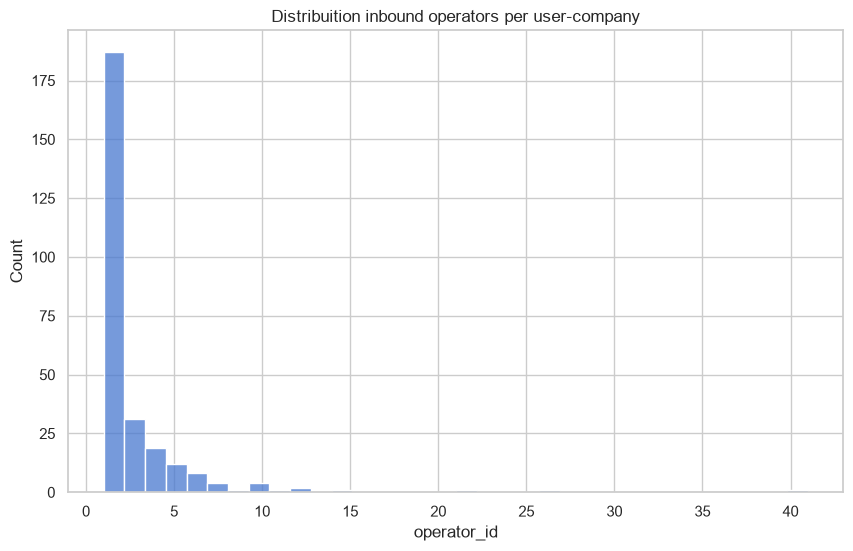

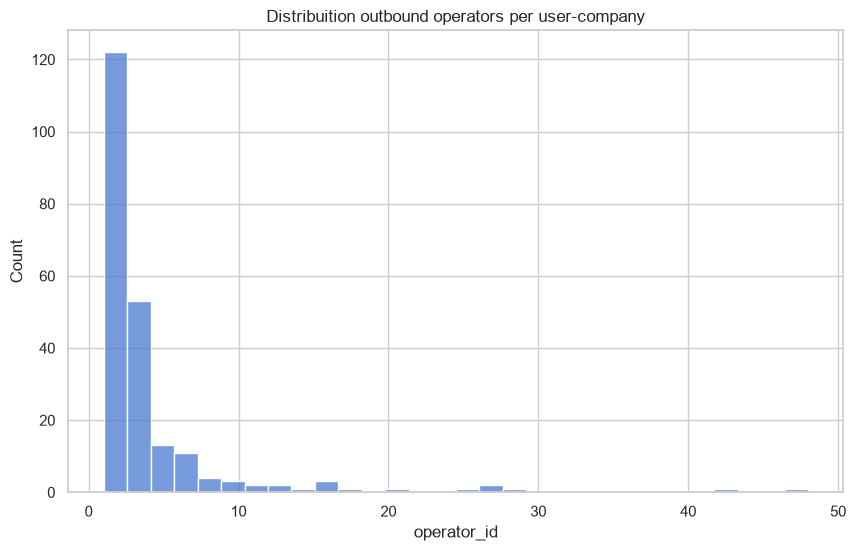

In [47]:
# visualização distribuição número de operadores inbound por empresa
sns.histplot(telecom_ops[telecom_ops['direction'] == 'in'].groupby('user_id')['operator_id'].nunique())
plt.title('Distribuition inbound operators per user-company')
plt.show()

# visualização distribuição número de operadores outbound por empresa
sns.histplot(telecom_ops[telecom_ops['direction'] == 'out'].groupby('user_id')['operator_id'].nunique())
plt.title('Distribuition outbound operators per user-company')
plt.show()

In [48]:
# visualização características número de operadores por empresa-cliente
telecom_ops[telecom_ops['direction'] == 'in'].groupby('user_id')['operator_id'].nunique().describe(percentiles=[.25, .50, .75, .85, .90, .95])

count   273.00
mean      2.76
std       3.65
min       1.00
25%       1.00
50%       2.00
75%       3.00
85%       4.00
90%       5.00
95%       8.00
max      41.00
Name: operator_id, dtype: float64

In [49]:
# visualização características número de operadores por empresa-cliente
telecom_ops[telecom_ops['direction'] == 'out'].groupby('user_id')['operator_id'].nunique().describe(percentiles=[.25, .50, .75, .85, .90, .95])

count   222.00
mean      3.97
std       5.97
min       1.00
25%       1.00
50%       2.00
75%       4.00
85%       5.85
90%       7.90
95%      13.95
max      48.00
Name: operator_id, dtype: float64

In [50]:
# contagem exata de empresas com apenas 1 operador inbound
telecom_ops[telecom_ops['direction'] == 'in'].groupby('user_id')['operator_id'].nunique().eq(1).sum()

np.int64(114)

In [51]:
# contagem exata de empresas com apenas 1 operador outbound
telecom_ops[telecom_ops['direction'] == 'out'].groupby('user_id')['operator_id'].nunique().eq(1).sum()

np.int64(79)

Volume de operadores inbound: 
 * 114 empresas-cliente (~41.8% das 273 com atividade inbound) possuem apenas 1 operador inbound registado no período., enquanto no Q3 o valor está próximo de 3 (50% superior a mediana).
 * O caso mais extremo é de uma empresas-cliente registrada com 41 operadores inbound, um valor ~24x superior a mediana observada.

Volume de operadores outbound: 
 * Outbound: 79 empresas (~35.6% das 222 com atividade outbound) possuem apenas 1 operador outbound registado no período, enquanto no Q3 o valor está próximo de 4 (~2x superior a mediana).
 * O caso mais extremo é de uma empresas-cliente registrada com 48 operadores outbound, um valor ~24x superior a mediana observada.

#### Distribuição taxa de chamadas perdidas por operador inbound

In [52]:
# cração agregado para taxa de chamadas perdidas por operador 
op_missed_ratio = (
    telecom_ops[telecom_ops['direction'] == 'in']
    .groupby('operator_id')['calls_count']
    .sum()
    .reset_index()
)

In [53]:
# descoberta número de operadores com atividade inbound
op_missed_ratio['operator_id'].nunique()

754

In [54]:
# contagem de chamadas inbound perdidas por operador
op_missed_inbound_calls = (
    telecom_ops[
        (telecom_ops['direction'] == 'in') &
        (telecom_ops['is_missed_call'] == True)
    ]
    .groupby('operator_id', as_index=False)['calls_count']
    .sum()
    .rename(columns={'calls_count': 'missed_calls'})
)

In [55]:
# descoberta número de operadores com chamadas inbound perdidas
op_missed_inbound_calls['operator_id'].nunique()

239

In [56]:
# união resultado ao agregado
op_missed_ratio = op_missed_ratio.merge(
    op_missed_inbound_calls,
    on='operator_id',
    how='left'
)

In [57]:
# preenchimento 0 aos operadores que não possuem registro de chamadas perdidas
op_missed_ratio['missed_calls'] = op_missed_ratio['missed_calls'].fillna(0)

In [58]:
# criação coluna ratio 
op_missed_ratio['missed_rate'] = op_missed_ratio['missed_calls'] / op_missed_ratio['calls_count'] 

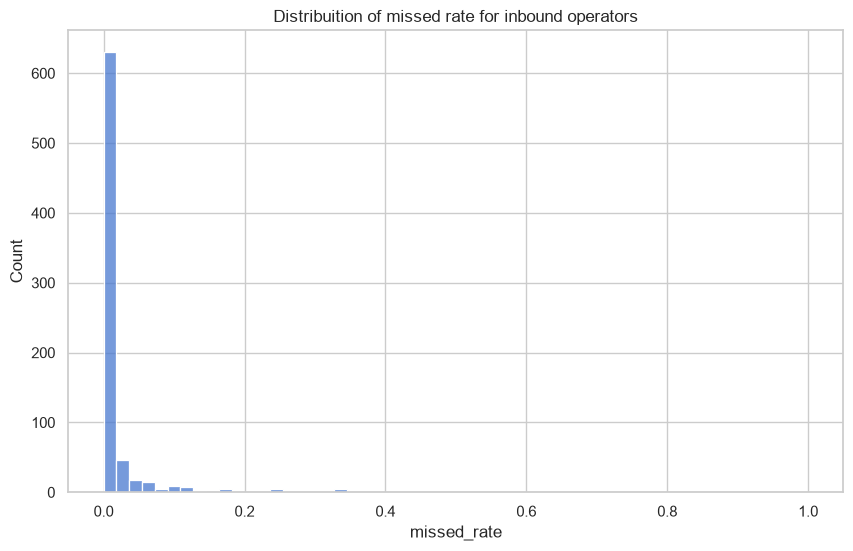

In [59]:
# visualização distribuição da taxa de chamadas perdidas por operador
sns.histplot(data=op_missed_ratio['missed_rate'])
plt.title('Distribuition of missed rate for inbound operators')
plt.show()

In [60]:
# descoberta características sobre taxa de chamadas perdidas
op_missed_ratio['missed_rate'].describe(percentiles=[.25, .50, .75, .85, .90, .95])

count   754.00
mean      0.02
std       0.07
min       0.00
25%       0.00
50%       0.00
75%       0.01
85%       0.02
90%       0.04
95%       0.09
max       1.00
Name: missed_rate, dtype: float64

75% dentre todos os 754 operadores inbound, possui taxa de chamadas perdidas inferior a 1%.

O caso mais extremo é de um operador com taxa de chamadas perdidas a 100%.

Dentre os 239 operadores que possuem taxa de chamadas perdidas superior a 0, até 75% destes estão abaixo de 5%.

#### Distribuição mediana do tempo de espera por operador inbound

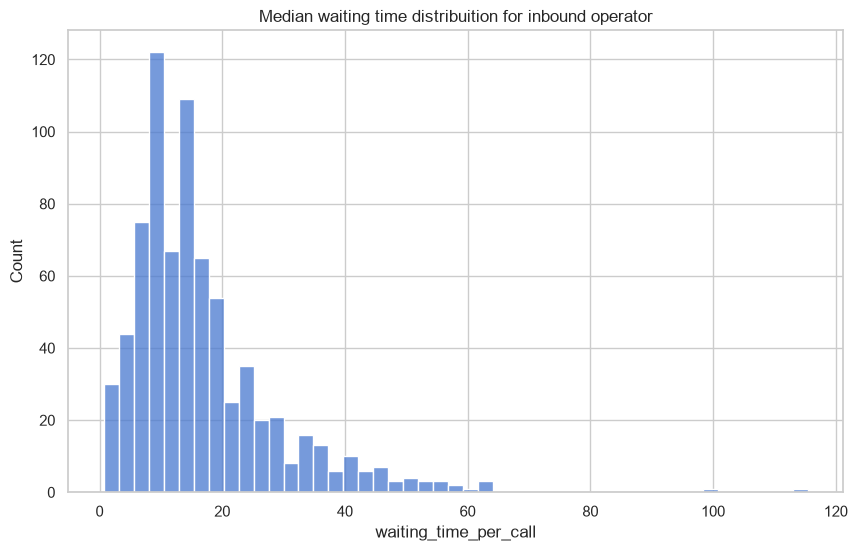

In [88]:
# visualização distribuição mediana do tempo de espera 
sns.histplot(telecom_ops[telecom_ops['direction'] == 'in'].groupby('operator_id')['waiting_time_per_call'].median())
plt.title('Median waiting time distribuition for inbound operator')
plt.show()

In [ ]:
# descoberta características sobre mediana do tempo de espera inbound
telecom_ops[telecom_ops['direction'] == 'in'].groupby('operator_id')['waiting_time_per_call'].median().describe(percentiles=[.25, .50, .66, .75, .85, .90, .95])

count   754.00
mean     16.61
std      12.21
min       0.67
25%       9.00
50%      13.67
66%      17.00
75%      20.18
85%      27.00
90%      33.50
95%      40.59
max     115.50
Name: waiting_time_per_call, dtype: float64

Dentre todos os 754 operadores inbound, metade deles possue mediana do tempo de espera inferior a 14s. Enquanto o Q3 está em 20s (~1.5x superior a mediana).

O caso mais extremo é de um operador com a mediana do tempo de espera em 115s, valor ~8x superior ao observado dentre a mediana dos operadores.

#### Distribuição da proporção de chamadas inbound e outbound por operador

In [63]:
# criação agregado proporção de chamadas inbound por operador
op_proportion = telecom_ops.groupby('operator_id').apply(
    lambda g: g[g['direction'] == 'in']['calls_count'].sum() / g['calls_count'].sum()
).reset_index(name='proportion_in')

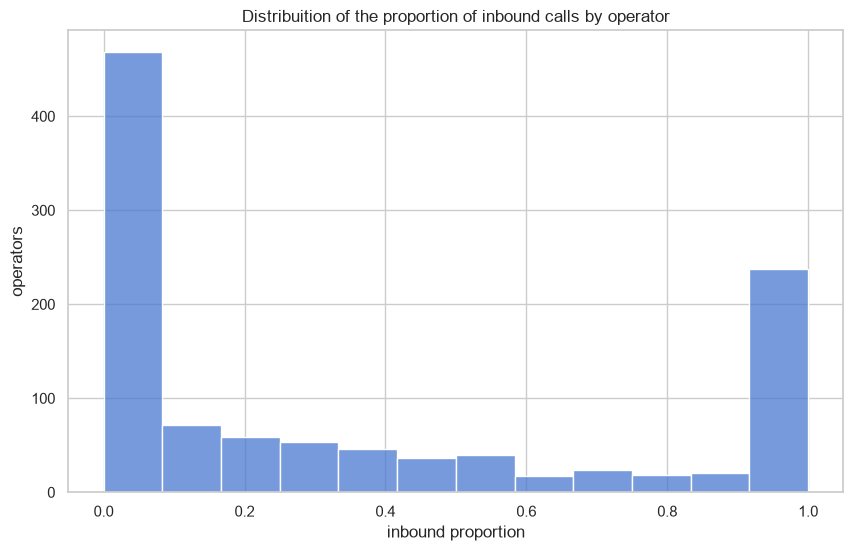

In [64]:
# distribuição da proporção de chamadas inbound por operador
sns.histplot(data=op_proportion, x='proportion_in')
plt.title('Distribuition of the proportion of inbound calls by operator')
plt.xlabel('inbound proportion')
plt.ylabel('operators')
plt.show()

In [65]:
# visualização características distribuição proporção de chamadas inbound por operador
print(op_proportion['proportion_in'].describe(percentiles=[.25, .33, .50, .66, .75]))

count   1092.00
mean       0.36
std        0.40
min        0.00
25%        0.00
33%        0.01
50%        0.17
66%        0.47
75%        0.75
max        1.00
Name: proportion_in, dtype: float64


In [66]:
# criação coluna proporção de chamadas outbound
op_proportion['proportion_out'] = 1 - op_proportion['proportion_in']

In [67]:
# visualização quantidade de operadores com proporção inbound e outbound > 66%
print(f'Operadores com proporção inbound >= 66%: {(op_proportion["proportion_in"] >= 0.66).sum()}')
print(f'Operadores com proporção outbound >= 66%: {(op_proportion["proportion_out"] >= 0.66).sum()}')

Operadores com proporção inbound >= 66%: 300
Operadores com proporção outbound >= 66%: 662


A distribuição da proporção de chamadas inbound por operador é fortemente bimodal: uma concentração de operadores com proporção próxima de 0 (exclusivamente outbound) e outra com proporção próxima de 1 (exclusivamente inbound), com poucos operadores verdadeiramente mistos.

Aplicando o threshold de 66% em ambos os sentidos:
- 300 operadores (~27.5%) têm proporção inbound ≥ 66%
  — predominantemente inbound, avaliados nos KPIs 1 e 2
- 662 operadores (~60.6%) têm proporção outbound ≥ 66%
  — predominantemente outbound, avaliados no KPI 3
- 130 operadores (~11.9%) não atingem 66% em nenhuma direcção
  — perfil misto, excluídos de todos os KPIs por ausência de maioria clara

O threshold de 66% é consistente entre os três KPIs — a cada três chamadas, pelo menos duas devem ser do tipo avaliado para que a avaliação seja metodologicamente defensável.

### Síntese da EDA

A análise exploratória revela quatro padrões estruturais que orientam a avaliação de operadores:

**1. Concentração de volume extrema** -
Tanto em inbound como outbound, a distribuição de chamadas por operador é fortemente assimétrica. A maioria dos operadores tem volume baixo (mediana inbound: 17 chamadas; mediana outbound: 90 chamadas), enquanto um número reduzido de operadores concentra volumes muito superiores. Isto justifica a um inclusão de critério de volume mínimo a um operador na avaliação.

**2. Missed rate inbound concentrada em valores baixos** -
75% dos 754 operadores inbound têm taxa de chamadas perdidas inferior a 1%. Os operadores com desvio relevante são uma minoria — o que torna a identificação de outliers mais precisa e reduz o risco de falsos positivos.

**3. Waiting time com cauda longa**
A mediana de `waiting_time_per_call` entre operadores inbound é de 14 segundos, mas o Q3 já está em 21 segundos e o caso extremo por operador atinge 115 segundos (mediana individual). A distribuição justifica o uso de medianas (em vez de médias) e de thresholds baseados em percentis na avaliação.

**4. Estrutura de empresas predominantemente pequena** - 
Metade das empresas-cliente tem ≤ 2 operadores inbound/outbound activos no período. Equipas pequenas aumentam a sensibilidade da avaliação: comparações estatísticas entre um operador e a sua equipa tornam-se menos estáveis com amostras reduzidas. Este facto é documentado como limitação da análise, não como critério de exclusão.

**5. Crescimento acelerado** -
o volume de chamadas cresceu ~10x de agosto a novembro, puxado pelo outbound. Isso aumenta a relevância da análise de produtividade.

**6. Assimetria estrutural dos nulos** - 
27.3% das chamadas perdidas não têm operador associado, o que limita a análise a chamadas efectivamente atribuídas.

# **Cálculo KPIs e Identificação de Ineficiência**

## Definição de KPIs

### KPI 1 — Missed Rate (inbound)

Fórmula: total chamadas inbound perdidas do operador / total de chamadas inboud recebidas.

Para comparação de proporções entre operador e equipe (sem o trabalhador).

Critérios de identificação de ineficiência (todos devem ser satisfeitos):

**1. Volume mínimo — P25 local por equipa**

Um threshold global ignoraria a diferença de escala entre empresas. O volume mínimo é definido com base na distribuição da equipa em que o operador está inserido:

- Equipas com ≥ 3 operadores: operador deve atingir o P25 do volume de chamadas inbound da sua equipa
- Equipas com 2 operadores: o operador com menor volume deve ter pelo menos 66% (2/3) do volume do colega
- Equipas com 1 operador: excluídos da avaliação por ausência de grupo de referência válido. A comparação com operadores de outras empresas não é aplicável — o contexto operacional varia entre clientes.

**2. Significância estatística: p < 0.05**

Teste: Z-test de duas proporções (operador vs. restante da equipa)

**3. Operador acima do P85 da distribuição de missed_rate da equipa**

P85 verificado em EDA para operadores globalmente: 0.02 (2%). Separa variação natural de outliers com base na distribuição observada na EDA - referência descritiva - (mediana global: 0.00 e Q3 0.01).

**4. Critério de inclusão — proporção inbound ≥ 66%**

Apenas operadores com pelo menos 66% das suas chamadas no sentido inbound são avaliados neste KPI (A cada três chamadas, ao menos 2 são outbound).
Justificação: avaliar produtividade outbound de operadores com função predominantemente outbound não é metodologicamente defensável. Operadores no escopo: 300 de 1092 (~27.5%)

### KPI 2 — Waiting Time (inbound)

Fórmula: mediana do tempo de espera por chamada do operador (`waiting_time` / `calls_count`)

Critérios de identificação de ineficiência (todos devem ser satisfeitos):

**1. Volume mínimo — P25 local por equipa**

Mesma lógica do KPI 1:

- Equipas com ≥ 3 operadores: operador deve atingir o P25 do volume de chamadas inbound da sua equipa
- Equipas com 2 operadores: o operador com menor volume deve ter pelo menos 75% do volume do colega
- Equipas com 1 operador: excluídos da avaliação por ausência de grupo de referência válido.

**2. Significância estatística: p < 0.05**

Teste: Mann-Whitney U (operador vs. restante da equipa) Justificação: distribuição de waiting_time confirmada como fortemente assimétrica na EDA — teste não-paramétrico adequado.

**3. Operador acima do P85 da distribuição de medianas da equipa**

P85 verificado em EDA para operadores globalmente: 27.5 segundos. Separa variação natural de outliers com base na distribuição observada na EDA - referência descritiva - (mediana global: 13s, Q3: 21s). 
Na avaliação individual, o P85 é calculado localmente dentro da equipa de cada operador.

**4. Critério de inclusão — proporção inbound ≥ 66%**

Apenas operadores com pelo menos 66% das suas chamadas no sentido inbound são avaliados neste KPI (A cada três chamadas, ao menos 2 são outbound).
Justificação: avaliar produtividade outbound de operadores com função predominantemente outbound não é metodologicamente defensável. Operadores no escopo: 300 de 1092 (~27.5%)

### KPI 3 — Produtividade Outbound


#### Observação produtividade outbound a nível semanal

In [68]:
# mediana semanal de chamadas outbound por operador
weekly_outbound = (
    telecom_ops[telecom_ops['direction'] == 'out']
    .groupby(['operator_id', 'week'])['calls_count']
    .sum()
    .reset_index()
)

op_weekly_median = weekly_outbound.groupby('operator_id')['calls_count'].median()
op_weekly_median.describe(percentiles=[.05, .10, .15, .20, .25, .30, .35, .40, .45, .50, .75])

count    882.00
mean     107.14
std      317.14
min        1.00
5%         1.00
10%        1.05
15%        2.00
20%        3.00
25%        4.00
30%        5.00
35%        7.00
40%        9.00
45%       12.00
50%       16.00
75%       85.75
max     5191.00
Name: calls_count, dtype: float64

In [69]:
# operadores com proporção outbound >= 66%
ops_outbound = op_proportion[op_proportion['proportion_out'] >= 0.66]['operator_id']

In [ ]:
# mediana semanal restrita operadores predominantemente outbound
weekly_outbound = (
    telecom_ops[
        (telecom_ops['direction'] == 'out') &
        (telecom_ops['operator_id'].isin(ops_outbound))
    ]
    .groupby(['operator_id', 'week'])['calls_count']
    .sum()
    .reset_index()
)

op_weekly_median = weekly_outbound.groupby('operator_id')['calls_count'].median()
op_weekly_median.describe(percentiles=[.10, .15, .20, .25, .50, .66,.75, .90, .95, .100])

count    662.00
mean     135.29
std      360.52
min        1.00
10%        2.00
15%        3.00
20%        5.00
25%        6.00
50%       28.00
75%      133.62
max     5191.00
Name: calls_count, dtype: float64

#### Classificação

Fórmula: mediana semanal de chamadas outbound do operador

Critérios de identificação de ineficiência (todos devem ser satisfeitos):

**1. Critério de inclusão — proporção outbound ≥ 66%**

Apenas operadores com pelo menos 66% das suas chamadas no sentido outbound são avaliados neste KPI (A cada três chamadas, ao menos 2 são outbound).
Justificação: avaliar produtividade outbound de operadores com função predominantemente inbound não é metodologicamente defensável. Operadores no escopo: 662 de 1092 (~60.6%)

**2. Volume mínimo — P25 local por equipa**

Mesma lógica dos KPIs 1 e 2:

- Equipas com ≥ 3 operadores: operador deve atingir o P25 do volume semanal de chamadas outbound da sua equipa
- Equipas com 2 operadores: o operador com menor volume deve ter pelo menos 66% do volume do colega
- Equipas com 1 operador: excluídos da avaliação por ausência de grupo de referência válido.

**3. Significância estatística: p < 0.05**

Teste: Mann-Whitney U (operador vs. restante da equipa) Justificação: distribuição de calls_count confirmada como fortemente assimétrica na EDA — teste não-paramétrico adequado.

**4. Operador abaixo do P15 da distribuição de medianas semanais da equipa**

P15 verificado em EDA - referência descritiva - para operadores globalmente (662 operadores com proporção outbound ≥ 66%): 3 chamadas/semana. Identifica operadores na cauda inferior da distribuição de produtividade dentro da sua equipa.

## Aplicação Funções Avaliativas

### Altas Taxas de Chamadas Perdidas

Objetivo da função avaliativa é identificar operadores com taxa de chamadas inbound perdidas estatisticamente superior à da sua equipe, distinguindo desvios relevantes de variação natural.

A avaliação é feita por empresa-cliente: cada operador é comparado exclusivamente com os colegas de equipe, preservando o contexto operacional de cada cliente. Operadores em equipes de apenas 1 elemento são excluídos automaticamente por ausência de grupo de referência válido. 

Um operador é classificado como ineficiente quando satisfaz simultaneamente:
 - Volume mínimo (P25 local ou rácio 66% para equipes de dois 2, piso global de 17 chamadas - mediana observada em EDA)
 - Operadores predominantemente inbound (pelo menos 66%) 
 - Significância estatística: p < 0.05 (Z-test de duas proporções - chamadas atendidas e perdidas operador x chamadas atendidas e perdidas resto da equipe)
 - Missed rate acima do P85 da distribuição da equipe 

In [71]:
def evaluate_missed_rate(telecom_ops):

    # filtro inbound
    data = telecom_ops[telecom_ops['direction'] == 'in'].copy()
    results = []

    # proporção inbound por operador 
    op_proportion_in = telecom_ops.groupby('operator_id').apply(
        lambda g: g[g['direction'] == 'in']['calls_count'].sum() / g['calls_count'].sum()
    )
    ops_predominantly_inbound = op_proportion_in[op_proportion_in >= 0.66].index

    # criação loop por usuário-empresa para filtro mínimo de operadores
    for user in data['user_id'].unique():
        user_data = data[data['user_id'] == user]
        team_operators = user_data['operator_id'].nunique()
        
        # exclusão equipes com apenas 1 operador
        if team_operators == 1:
            continue
        
        # teste volume para equipes com apenas 2 operadores
        elif team_operators == 2:
            duo_volume = user_data.groupby('operator_id')['calls_count'].sum()
            min_calls = duo_volume.min()
            max_calls = duo_volume.max()
            if min_calls / max_calls < 0.66: 
                continue
            else:
                valid_duo_volume = duo_volume[duo_volume >= 17]
                valid_operators = valid_duo_volume.index
                valid_operators = [op for op in valid_operators if op in ops_predominantly_inbound]
                valid_data = user_data[user_data['operator_id'].isin(valid_operators)]
        
        # teste volume de chamadas para equipes com 3 ou mais operadores
        else:
            team_volume = user_data.groupby('operator_id')['calls_count'].sum()
            p25 = team_volume.quantile(0.25)
            valid_team_volume = team_volume[(team_volume >= p25) & (team_volume >= 17)]
            valid_operators = valid_team_volume.index
            valid_data = user_data[user_data['operator_id'].isin(valid_operators)]
        
        # aplicação filtro proporção inbound >= 66%
        valid_operators = [op for op in valid_operators if op in ops_predominantly_inbound]

        if len(valid_operators) <= 1:
            continue
        
        valid_data = user_data[user_data['operator_id'].isin(valid_operators)]

        # criação loop por operador para segregação de dados individuais e equipe
        for operator in valid_operators:    
            op_data = valid_data[valid_data['operator_id'] == operator]
            team_data = valid_data[valid_data['operator_id'] != operator]
            op_calls = op_data['calls_count'].sum()
            op_missed = op_data[op_data['is_missed_call'] == True]['calls_count'].sum() 
            team_calls = team_data['calls_count'].sum()
            if team_calls == 0:
                continue
            team_missed = team_data[team_data['is_missed_call'] == True]['calls_count'].sum()
            op_missed_rate = op_missed / op_calls
            team_missed_rate = team_missed / team_calls if team_calls > 0 else 0.0
            team_rates = valid_data.groupby('operator_id').apply(lambda g: g[g['is_missed_call'] == True]['calls_count'].sum() / g['calls_count'].sum())
            p85_threshold = team_rates.quantile(0.85)

            # aplicação Two-proportion z-test
            count = np.array([op_missed, team_missed])
            nobs = np.array([op_calls, team_calls])
            if count.sum() == 0:
                continue
            stat, p_value = proportions_ztest(count, nobs)

            # critérios de ineficiência
            fail = p_value < 0.05 and op_missed_rate > p85_threshold

            # lista com resultados por cada ciclo de operador
            results.append({
                'operator_id' : operator,
                'user_id' : user,
                'op_calls': op_calls,
                'team_calls' : team_calls,
                'n_references' : team_data['operator_id'].nunique(),
                'op_missed_rate' : round(op_missed_rate, 4),
                'team_missed_rate' : round(team_missed_rate, 4),
                'p85_threshold' : round(p85_threshold, 4),
                'p_value' : round(p_value, 4),
                'fail_missed_rate' : fail
            })
    # transformação lista de resultados em dataframe
    df = pd.DataFrame(results)
    df = df.sort_values(by=['fail_missed_rate', 'op_missed_rate'], ascending=False)
    return df

In [72]:
# aplicação da função de avaliação de operadores
results_missed_rate = evaluate_missed_rate(telecom_ops)

In [104]:
# descoberta operadores que falharam no teste estatísitco de proporções
print(f'Número de operadores avaliados no total: {results_missed_rate.shape[0]}')
flagged_missed_rate = results_missed_rate[results_missed_rate['fail_missed_rate'] == True].copy()
print(f'Operadores que reporvaram em teste estatístico: {len(flagged_missed_rate)}')

Número de operadores avaliados no total: 55
Operadores que reporvaram em teste estatístico: 4


In [105]:
# visualização operadores flagged
flagged_missed_rate

,operator_id,user_id,op_calls,team_calls,n_references,op_missed_rate,team_missed_rate,p85_threshold,p_value,fail_missed_rate
33,937368.0,167580,22,25,1,0.18,0.00,0.15,0.03,True
16,911102.0,167059,27,590,4,0.11,0.01,0.10,0.00,True
4,908960.0,166541,694,973,2,0.02,0.00,0.02,0.00,True
22,919554.0,167264,1181,1087,1,0.01,0.00,0.01,0.01,True


#### Resultados — Missed Rate

**4 operadores** identificados com missed rate estatisticamente superior à da sua equipa, sobre um universo de 55 operadores avaliados (~7.3%).

O universo de 55 operadores resulta da aplicação sequencial de três filtros: proporção inbound ≥ 66%, volume mínimo (P25 local e piso de 17 chamadas) e equipa com pelo menos 2 operadores válidos após todos os filtros.

##### Magnitude

**Impacto crítico** (missed rate ≥ 10%):
- Operador 937368.0 (empresa 167580): 18% vs. 0% da equipa — 1 referência
- Operador 911102.0 (empresa 167059): 11% vs. 1% da equipa — 4 referências

**Impacto baixo** (missed rate < 5%):
- Operador 908960.0 (empresa 166541): 2% vs. 0% da equipa — 2 referências
- Operador 919554.0 (empresa 167264): 1% vs. 0% da equipa — 1 referência

##### Robustez


Os operadores 937368.0 e 919554.0 têm `n_references = 1` — são comparados contra apenas 1 colega. Os resultados são estatisticamente significativos (p = 0.03 e p = 0.01 respectivamente), mas devem ser interpretados com cautela dado o tamanho reduzido do grupo de referência.

##### Padrão por empresa-cliente

Cada um dos 4 operadores flagged pertence a uma empresa distinta — não há evidência de padrão estrutural por empresa neste KPI.

### Elevada Mediana do Tempo de Espera

O objetivo da função avaliativa é identificar operadores com tempo de espera por chamada estatisticamente superior ao da sua equipa, distinguindo desvios relevantes de variação natural.

A avaliação é feita por empresa-cliente: cada operador é comparado exclusivamente com os colegas de equipa, preservando o contexto operacional de cada cliente. Operadores em equipas de apenas 1 elemento são excluídos automaticamente por ausência de grupo de referência válido.

Um operador é classificado como ineficiente quando satisfaz simultaneamente:
- Volume mínimo (P25 local ou rácio 66% para equipas de 2, piso global de 17 chamadas — mediana observada na EDA)
- Operador predominantemente inbound (proporção inbound ≥ 66%)
- Significância estatística: p < 0.05 (Mann-Whitney — distribuição de waiting_time_per_call do operador vs. restante da equipa)
- Mediana de waiting_time_per_call acima do P85 da distribuição das medianas da equipa (referência global: 27 segundos)

In [92]:
def evaluate_waiting_time(telecom_ops):

    # filtro inbound
    data = telecom_ops[telecom_ops['direction'] == 'in'].copy()
    results = []

    # proporção inbound por operador
    op_proportion_in = telecom_ops.groupby('operator_id').apply(
        lambda g: g[g['direction'] == 'in']['calls_count'].sum() / g['calls_count'].sum()
    )
    ops_predominantly_inbound = op_proportion_in[op_proportion_in >= 0.66].index

    for user in data['user_id'].unique():
        user_data = data[data['user_id'] == user]
        team_operators = user_data['operator_id'].nunique()

        if team_operators == 1:
            continue

        elif team_operators == 2:
            duo_volume = user_data.groupby('operator_id')['calls_count'].sum()
            min_calls = duo_volume.min()
            max_calls = duo_volume.max()
            if min_calls / max_calls < 0.66:
                continue
            else:
                valid_duo_volume = duo_volume[duo_volume >= 17]
                valid_operators = valid_duo_volume.index

        else:
            team_volume = user_data.groupby('operator_id')['calls_count'].sum()
            p25 = team_volume.quantile(0.25)
            valid_team_volume = team_volume[(team_volume >= p25) & (team_volume >= 17)]
            valid_operators = valid_team_volume.index

        # filtro proporção inbound >= 66%
        valid_operators = [op for op in valid_operators if op in ops_predominantly_inbound]

        if len(valid_operators) <= 1:
            continue

        valid_data = user_data[user_data['operator_id'].isin(valid_operators)]

        for operator in valid_operators:
            op_data = valid_data[valid_data['operator_id'] == operator]
            team_data = valid_data[valid_data['operator_id'] != operator]

            op_waiting = op_data['waiting_time_per_call']
            team_waiting = team_data['waiting_time_per_call']

            if len(team_waiting) == 0:
                continue

            op_median = op_waiting.median()
            team_median = team_waiting.median()

            # P85 das medianas de waiting_time da equipa
            team_medians = valid_data.groupby('operator_id')['waiting_time_per_call'].median()
            p85_threshold = team_medians.quantile(0.85)

            # Mann-Whitney U
            stat, p_value = st.mannwhitneyu(
                op_waiting, team_waiting, alternative='greater'
            )

            fail = p_value < 0.05 and op_median > p85_threshold

            results.append({
                'operator_id': operator,
                'user_id': user,
                'op_waiting_median': round(op_median, 1),
                'team_waiting_median': round(team_median, 1),
                'n_references': team_data['operator_id'].nunique(),
                'p85_threshold': round(p85_threshold, 1),
                'p_value': round(p_value, 4),
                'fail_waiting_time': fail
            })

    df = pd.DataFrame(results)
    df = df.sort_values(by=['fail_waiting_time', 'op_waiting_median'], ascending=False)
    return df

In [93]:
# aplicação da função de avaliação de operadores
results_waiting_time = evaluate_waiting_time(telecom_ops)

In [106]:
# descoberta operadores que falharam no teste estatísitco de proporções
print(f'Número de operadores avaliados no total: {results_waiting_time.shape[0]}')
flagged_waiting_time = results_waiting_time[results_waiting_time['fail_waiting_time'] == True].copy()
print(f'Operadores que reporvaram em teste estatístico: {len(flagged_waiting_time)}')

Número de operadores avaliados no total: 65
Operadores que reporvaram em teste estatístico: 16


In [107]:
# visualização operadores flagged
flagged_waiting_time

,operator_id,user_id,op_waiting_median,team_waiting_median,n_references,p85_threshold,p_value,fail_waiting_time
37,944228.0,167521,53.50,27.10,7,35.30,0.00,True
24,911142.0,167059,46.50,20.00,4,33.90,0.00,True
13,927070.0,166879,42.50,18.20,2,42.20,0.00,True
0,891900.0,166392,40.50,26.00,1,38.30,0.00,True
42,937374.0,167580,36.70,16.50,1,33.60,0.00,True
36,944210.0,167521,35.50,27.10,7,35.30,0.04,True
29,919552.0,167264,34.20,32.10,1,33.90,0.00,True
8,893420.0,166604,29.00,13.20,1,26.60,0.00,True
16,906408.0,166916,28.00,26.00,1,27.70,0.05,True
59,948286.0,168187,17.70,5.80,5,15.50,0.00,True


#### Resultados — Waiting Time

**16 operadores** identificados com tempo de espera por chamada estatisticamente superior ao da sua equipa, sobre um universo de 65 operadores avaliados (~24.6%).

##### Magnitude

**Impacto crítico** (mediana > 35 segundos):
- Operador 944228.0 (empresa 167521): 53.5s vs. 27.1s da equipa — 7 referências
- Operador 911142.0 (empresa 167059): 46.5s vs. 20.0s da equipa — 4 referências
- Operador 927070.0 (empresa 166879): 42.5s vs. 18.2s da equipa — 2 referências
- Operador 891900.0 (empresa 166392): 40.5s vs. 26.0s da equipa — 1 referência
- Operador 937374.0 (empresa 167580): 36.7s vs. 16.5s da equipa — 1 referência
- Operador 944210.0 (empresa 167521): 35.5s vs. 27.1s da equipa — 7 referências

**Impacto moderado** (mediana entre 15 e 35 segundos):
- Operador 919552.0 (empresa 167264): 34.2s vs. 32.1s da equipa — 1 referência
- Operador 893420.0 (empresa 166604): 29.0s vs. 13.2s da equipa — 1 referência
- Operador 906408.0 (empresa 166916): 28.0s vs. 26.0s da equipa — 1 referência
- Operador 948286.0 (empresa 168187): 17.7s vs. 5.8s da equipa — 5 referências
- Operador 895576.0 (empresa 166896): 17.0s vs. 14.0s da equipa — 1 referência
- Operador 956480.0 (empresa 167078): 14.7s vs. 6.2s da equipa — 1 referência
- Operador 920728.0 (empresa 167445): 13.5s vs. 10.0s da equipa — 1 referência

**Impacto baixo** (mediana < 15 segundos):
- Operador 940440.0 (empresa 167828): 9.2s vs. 1.0s da equipa — 1 referência
- Operador 919206.0 (empresa 167626): 7.7s vs. 6.5s da equipa — 3 referências
- Operador 940630.0 (empresa 168252): 4.1s vs. 3.1s da equipa — 1 referência

##### Robustez

10 dos 16 operadores flagged têm `n_references = 1` — são comparados contra apenas 1 colega. Os resultados são estatisticamente significativos (p < 0.05 em todos os casos), mas devem ser interpretados com cautela dado o tamanho reduzido do grupo de referência.

##### Padrão por empresa-cliente


- **Empresa-cliente 167521**: 2 operadores flagged (944228.0 e 944210.0) com os casos de maior magnitude — padrão consistente com problema estrutural
- **Empresa-cliente 167059**: 1 operador flagged em cada função avaliativa aplicada (KPI 2 - 911142.0, KPI 1 - 911102.0)
- As restantes 13 empresas apresentam 1 operador flagged cada

### Baixa Produtividade Outbound

O objetivo da função avaliativa é identificar operadores com produtividade outbound semanal estatisticamente inferior à da sua equipa, distinguindo desvios relevantes de variação natural.

A avaliação é feita por empresa-cliente: cada operador é comparado exclusivamente com os colegas de equipa, preservando o contexto operacional de cada cliente. Operadores em equipas de apenas 1 elemento são excluídos automaticamente por ausência de grupo de referência válido.

Um operador é classificado como ineficiente quando satisfaz simultaneamente:
- Volume mínimo (P25 local ou rácio 66% para equipas de 2, piso global de 28 chamadas/semana — mediana observada na EDA para operadores predominantemente outbound)
- Operador predominantemente outbound (proporção outbound ≥ 66%)
- Significância estatística: p < 0.05 (Mann-Whitney U — distribuição de chamadas semanais do operador vs. medianas semanais da equipa)
- Mediana semanal abaixo do P15 da distribuição das medianas da equipa

In [112]:
def evaluate_out_productivity(telecom_ops):

    # filtro outbound
    data = telecom_ops[telecom_ops['direction'] == 'out'].copy()
    results = []

    # proporção outbound por operador
    op_proportion_out = telecom_ops.groupby('operator_id').apply(
        lambda g: g[g['direction'] == 'out']['calls_count'].sum() / g['calls_count'].sum()
    )
    ops_predominantly_outbound = op_proportion_out[op_proportion_out >= 0.66].index

    for user in data['user_id'].unique():
        user_data = data[data['user_id'] == user]
        team_operators = user_data['operator_id'].nunique()

        if team_operators == 1:
            continue

        elif team_operators == 2:
            duo_weekly = (
                user_data.groupby(['operator_id', 'week'])['calls_count']
                .sum()
                .reset_index()
            )
            duo_volume = duo_weekly.groupby('operator_id')['calls_count'].median()
            min_calls = duo_volume.min()
            max_calls = duo_volume.max()
            if min_calls / max_calls < 0.66:
                continue
            else:
                # piso global
                valid_duo_volume = duo_volume[duo_volume >= 28]
                valid_operators = valid_duo_volume.index

        else:
            team_weekly = (
                user_data.groupby(['operator_id', 'week'])['calls_count']
                .sum()
                .reset_index()
            )
            team_volume = team_weekly.groupby('operator_id')['calls_count'].median()
            p25 = team_volume.quantile(0.25)
            # piso global
            valid_team_volume = team_volume[(team_volume >= p25) & (team_volume >= 28)]
            valid_operators = valid_team_volume.index

        # filtro proporção outbound >= 66%
        valid_operators = [op for op in valid_operators if op in ops_predominantly_outbound]

        if len(valid_operators) <= 1:
            continue

        valid_data = user_data[user_data['operator_id'].isin(valid_operators)]

        for operator in valid_operators:
            op_data = valid_data[valid_data['operator_id'] == operator]
            team_data = valid_data[valid_data['operator_id'] != operator]

            # mediana semanal por operador
            op_weekly = op_data.groupby('week')['calls_count'].sum()
            team_weekly_by_op = (
                team_data.groupby(['operator_id', 'week'])['calls_count']
                .sum()
                .reset_index()
            )
            team_weekly_medians = team_weekly_by_op.groupby('operator_id')['calls_count'].median()

            op_volume = op_weekly.median()
            team_volume = team_weekly_medians.median()

            if len(team_weekly_medians) == 0:
                continue

            # piso global
            if op_volume < 28:
                continue

            # P15 das medianas semanais da equipa
            p15_threshold = team_weekly_medians.quantile(0.15)

            # Mann-Whitney U (alternative='less' — operador abaixo da equipa)
            _, p_value = st.mannwhitneyu(
                op_weekly, team_weekly_medians, alternative='less'
            )

            fail = p_value < 0.05 and op_volume < p15_threshold

            results.append({
                'operator_id': operator,
                'user_id': user,
                'op_weekly_median': round(op_volume, 1),
                'team_weekly_median': round(team_volume, 1),
                'n_references': team_data['operator_id'].nunique(),
                'p15_threshold': round(p15_threshold, 1),
                'p_value': round(p_value, 4),
                'fail_out': fail
            })

    df = pd.DataFrame(results)
    df = df.sort_values(by=['fail_out', 'op_weekly_median'], ascending=True)
    return df

In [113]:
# aplicação da função de avaliação de operadores
results_out_productivity = evaluate_out_productivity(telecom_ops)

In [114]:
# descoberta operadores que falharam no teste estatísitco de proporções
print(f'Número de operadores avaliados no total: {results_out_productivity.shape[0]}')
flagged_out_productivity = results_out_productivity[results_out_productivity['fail_out'] == True].copy()
print(f'Operadores que reporvaram em teste estatístico: {len(flagged_out_productivity)}')

Número de operadores avaliados no total: 248
Operadores que reporvaram em teste estatístico: 28


In [115]:
flagged_out_productivity

,operator_id,user_id,op_weekly_median,team_weekly_median,n_references,p15_threshold,p_value,fail_out
188,937678.0,168187,28.00,100.00,19,45.40,0.00,True
18,923250.0,166520,29.00,74.00,3,67.00,0.02,True
91,924930.0,167497,29.00,35.50,5,32.60,0.04,True
182,958440.0,168091,30.00,96.50,8,53.80,0.01,True
193,937762.0,168187,30.00,100.00,19,45.40,0.00,True
30,890422.0,166658,30.50,73.00,8,60.30,0.02,True
31,891154.0,166658,34.00,73.00,8,60.30,0.00,True
201,937868.0,168187,41.50,100.00,19,42.50,0.01,True
243,952460.0,168412,43.50,286.00,5,84.00,0.03,True
167,947636.0,168062,49.00,258.00,19,97.40,0.00,True


#### Resultados — Outbound Productivity

**28 operadores** identificados com produtividade outbound semanal estatisticamente inferior à da sua equipa, sobre um universo de 248 operadores avaliados (~11.3%).

##### Magnitude


**Desvio crítico** (mediana semanal < 50 chamadas com equipa > 70):
- Operador 937678.0 (empresa 168187): 28.0 vs. 100.0 da equipa — 19 referências
- Operador 937762.0 (empresa 168187): 30.0 vs. 100.0 da equipa — 19 referências
- Operador 923250.0 (empresa 166520): 29.0 vs. 74.0 da equipa — 3 referências
- Operador 958440.0 (empresa 168091): 30.0 vs. 96.5 da equipa — 8 referências
- Operador 890422.0 (empresa 166658): 30.5 vs. 73.0 da equipa — 8 referências
- Operador 891154.0 (empresa 166658): 34.0 vs. 73.0 da equipa — 8 referências
- Operador 924930.0 (empresa 167497): 29.0 vs. 35.5 da equipa — 5 referências
- Operador 937868.0 (empresa 168187): 41.5 vs. 100.0 da equipa — 19 referências
- Operador 952460.0 (empresa 168412): 43.5 vs. 286.0 da equipa — 5 referências
- Operador 947636.0 (empresa 168062): 49.0 vs. 258.0 da equipa — 19 referências
- Operador 939218.0 (empresa 168021): 50.0 vs. 166.5 da equipa — 2 referências
- Operador 958432.0 (empresa 168091): 50.0 vs. 96.5 da equipa — 8 referências

**Desvio moderado** (mediana semanal entre 50 e 150 chamadas):
- Operador 887276.0 (empresa 166485): 65.0 vs. 209.5 da equipa — 3 referências
- Operador 905566.0 (empresa 167150): 66.0 vs. 165.0 da equipa — 3 referências
- Operador 905564.0 (empresa 167150): 66.5 vs. 165.0 da equipa — 3 referências
- Operador 947640.0 (empresa 168062): 69.0 vs. 258.0 da equipa — 19 referências
- Operador 940614.0 (empresa 168252): 70.0 vs. 368.0 da equipa — 9 referências
- Operador 947600.0 (empresa 168062): 79.5 vs. 258.0 da equipa — 19 referências
- Operador 947598.0 (empresa 168062): 82.0 vs. 258.0 da equipa — 19 referências

**Desvio baixo** (mediana semanal > 150 chamadas — desvio relativo relevante
mas volume absoluto elevado):
- Operador 919194.0 (empresa 167626): 250.5 vs. 415.5 da equipa — 35 referências
- Operador 902782.0 (empresa 167125): 255.0 vs. 466.0 da equipa — 5 referências
- Operador 902774.0 (empresa 167125): 264.5 vs. 466.0 da equipa — 5 referências
- Operador 919198.0 (empresa 167626): 273.0 vs. 415.5 da equipa — 35 referências
- Operador 919378.0 (empresa 167626): 320.5 vs. 415.5 da equipa — 35 referências
- Operador 921596.0 (empresa 167626): 322.0 vs. 415.5 da equipa — 35 referências
- Operador 945320.0 (empresa 168361): 336.5 vs. 415.0 da equipa — 19 referências
- Operador 945312.0 (empresa 168361): 347.0 vs. 415.0 da equipa — 19 referências
- Operador 945284.0 (empresa 168361): 347.5 vs. 415.0 da equipa — 19 referências

##### Padrão por empresa-cliente

Cinco empresas concentram múltiplos operadores flagged:

- **Empresa 168187**: 3 operadores flagged — padrão estrutural reforçado pela presença também no KPI 1 (3 operadores) e KPI 2 (1 operador)
- **Empresa 168062**: 4 operadores flagged
- **Empresa 167626**: 4 operadores flagged — equipas de grande dimensão (35 referências), o que aumenta a robustez dos resultados
- **Empresa 168361**: 3 operadores flagged
- **Empresa 166658**: 2 operadores flagged
- **Empresa 168091**: 2 operadores flagged
- **Empresa 167125**: 2 operadores flagged
- **Empresa 167150**: 2 operadores flagged

As restantes 7 empresas apresentam 1 operador flagged cada.

## A